# Detection de fraude avec arbre de decision

Dans ce notebook, on construit progressivement un premier pipeline de detection de fraude a partir d'un arbre de decision. L'objectif est de comprendre la structure des donnees, preparer un jeu de variables exploitable, puis evaluer si ce modele simple arrive a capter un signal utile.

# 1. Chargement et première inspection des données

Cette premiere etape permet de verifier la taille du dataset, les types de variables, la presence de valeurs manquantes et quelques problemes evidents de qualite des donnees avant de commencer l'analyse.

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

import optuna
from sklearn.model_selection import RandomizedSearchCV

In [79]:
df = pd.read_csv('data/Fraud Detection Dataset.csv')

In [80]:
print(f"La taille du dataset est de {df.shape[0]} lignes et {df.shape[1]} colonnes")

La taille du dataset est de 51000 lignes et 12 colonnes


In [81]:
print("Les informations sur les données :")
df.info()

Les informations sur les données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                      

On remarque deja que :
- certaines colonnes contiennent des valeurs manquantes, donc une etape de traitement sera necessaire ;
- le dataset melange des variables numeriques et des variables categorielles ;
- la cible `Fraudulent` est binaire, ce qui confirme qu'il s'agit d'un probleme de classification.

In [82]:
# visulisation des premières lignes du dataset
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [83]:
# Résumé des varaibles numériques
print("Résumé des variables numériques :")
df.describe().T

Résumé des variables numériques :


,count,mean,std,min,25%,50%,75%,max
User_ID,51000.0,3005.110176,1153.121107,1000.00,2007.0000,2996.0,4006.00,4999.0
Transaction_Amount,48480.0,2996.249784,5043.932555,5.03,1270.5525,2524.1,3787.24,49997.8
Time_of_Transaction,48448.0,11.488400,6.922954,0.00,5.0000,12.0,17.00,23.0
Previous_Fraudulent_Transactions,51000.0,1.995725,1.415150,0.00,1.0000,2.0,3.00,4.0
Account_Age,51000.0,60.033902,34.384131,1.00,30.0000,60.0,90.00,119.0
Number_of_Transactions_Last_24H,51000.0,7.495588,4.020080,1.00,4.0000,7.0,11.00,14.0
Fraudulent,51000.0,0.049216,0.216320,0.00,0.0000,0.0,0.00,1.0


> Les variables numeriques n'ont pas la meme echelle. Donc on va essayer de les normaliser à l'étape du prétraitement

In [84]:
# vérification des valeurs manquantes
print("Vérification des valeurs manquantes :")
print(df.isnull().sum())

Vérification des valeurs manquantes :
Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64


In [85]:
# verification des doublons
print("Vérification des doublons :")
print(f"Nombre de doublons : {df.duplicated().sum()}")

Vérification des doublons :
Nombre de doublons : 881


# 2. Analyse exploratoire des données (EDA)

> L'objectif ici est de mieux comprendre les distributions, les ordres de grandeur, les eventuelles anomalies et les relations entre variables afin d'orienter les choix de nettoyage et de modelisation.

## Analyse univariee

On commence par observer chaque variable prise isolement pour reperer les asymetries, les valeurs extremes et la nature des differentes colonnes.

### Variables numeriques

Les boxplots ci-dessous permettent de visualiser la dispersion des variables et la presence eventuelle de valeurs tres eloignees du coeur de distribution.

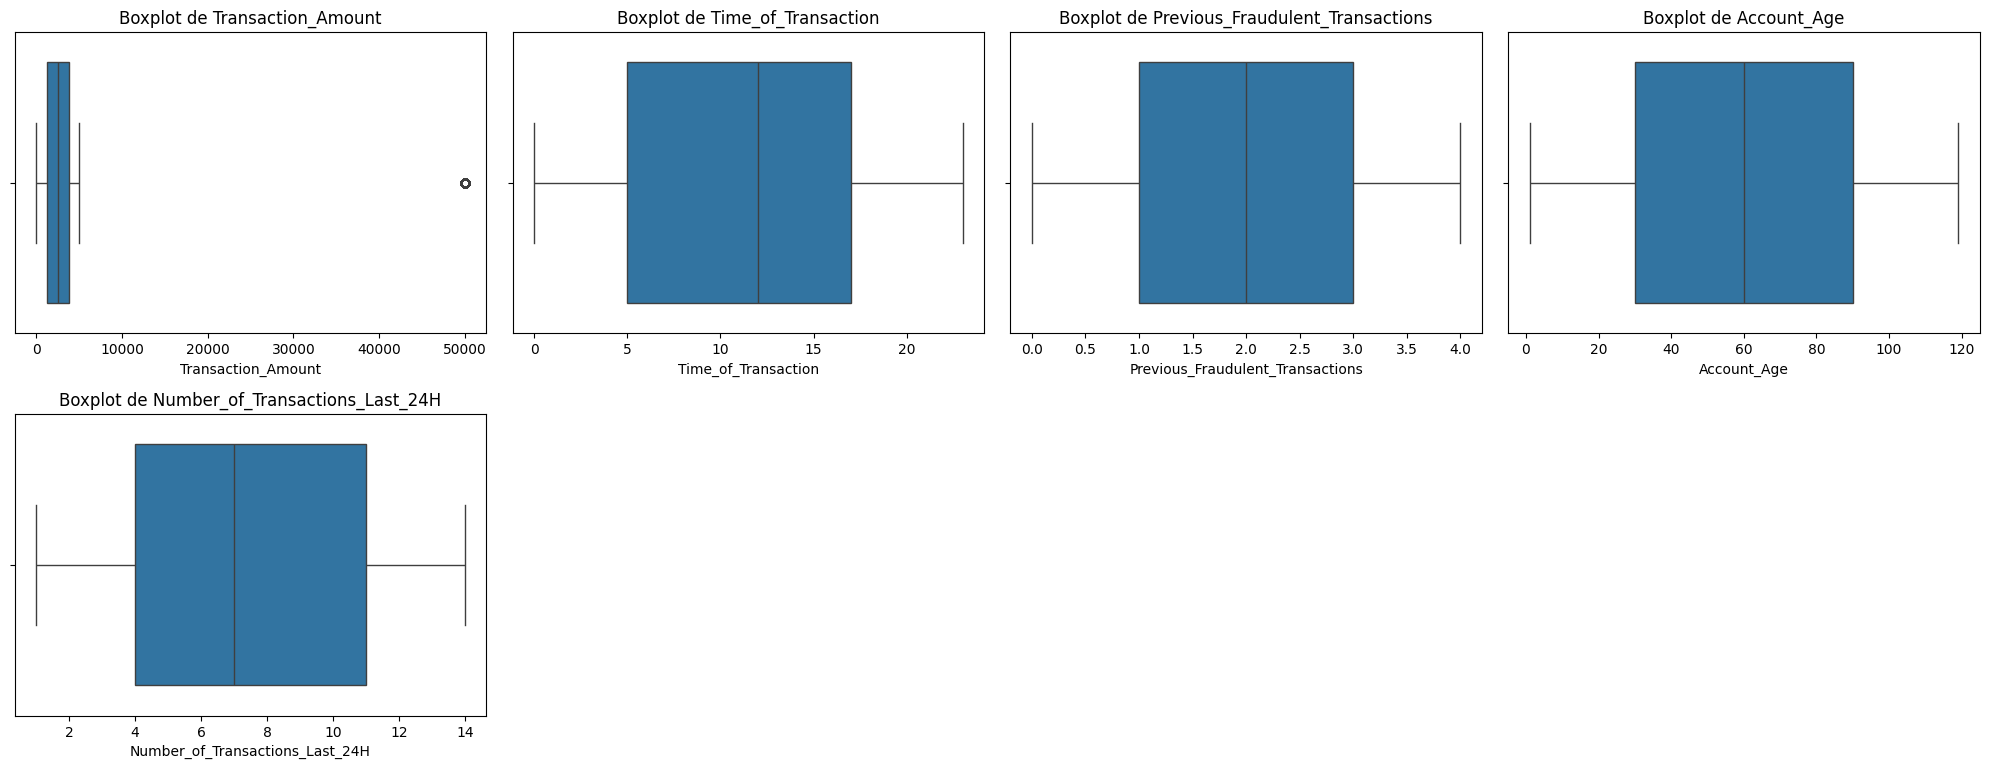

In [86]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Fraudulent')  # Exclure la variable cible
num_cols.remove('User_ID')  # Exclure l'identifiant de l'utilisateur

plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

In [87]:
# Nomnbre de transactions avec un montant supérieur à 40000 (les outliers)'
(df["Transaction_Amount"] > 40000).sum()

np.int64(508)

> La variable `Transaction_Amount` presente des valeurs elevees par rapport au reste de la distribution. On peut les considerer comme des valeurs extremes, mais pas automatiquement comme des valeurs aberrantes.

### Variables categorielles

Cette partie sert a examiner la repartition des modalites et a reperer d'eventuelles categories rares ou atypiques.

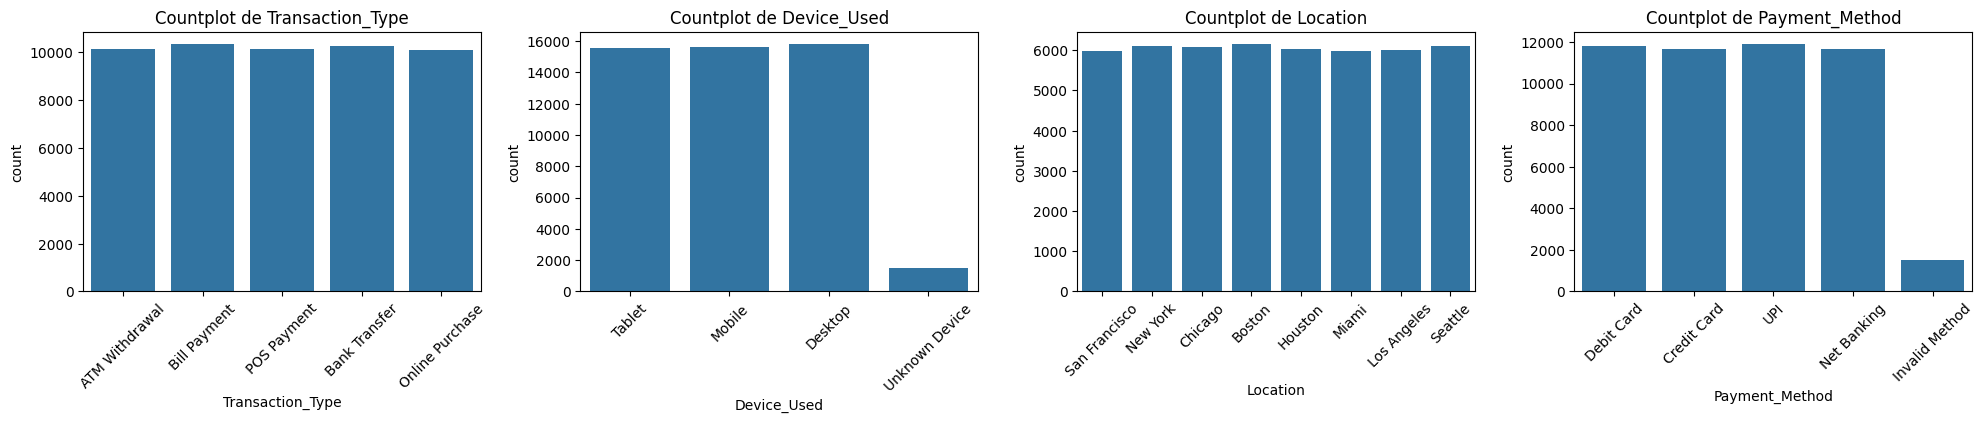

In [88]:
cat_cols = df.select_dtypes(include=['object']).columns.to_list()
cat_cols.remove('Transaction_ID')  # Exclure l'identifiant de transaction

plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(4, 4, i + 1)
    sns.countplot(x=df[col])
    plt.title(f'Countplot de {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Analyse bivariee

On etudie maintenant la relation entre les variables explicatives et la cible afin d'identifier les colonnes potentiellement informatives.

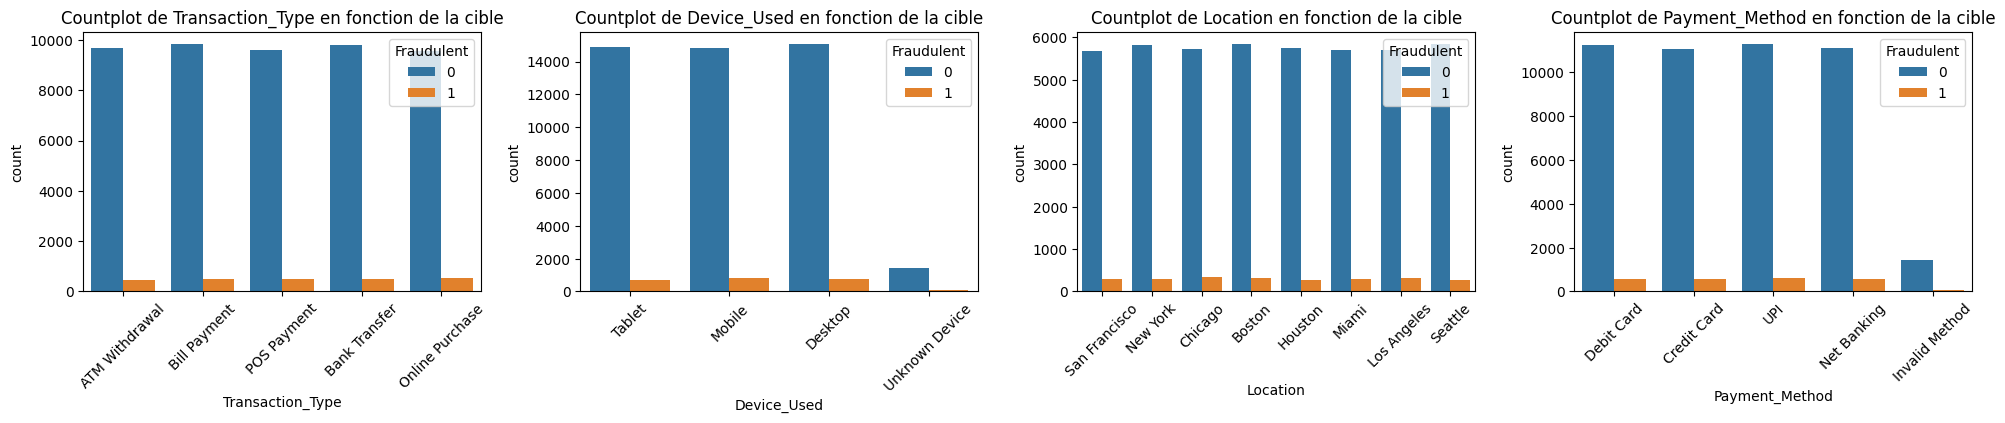

In [89]:
# analyse bivariée entre les variables catégorielles et la cible
plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(4, 4, i + 1)
    sns.countplot(x=df[col], hue=df['Fraudulent'])
    plt.title(f'Countplot de {col} en fonction de la cible')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> On observe visuellement un desequilibre de classes : la classe non frauduleuse domine la classe frauduleuse dans la plupart des categories.

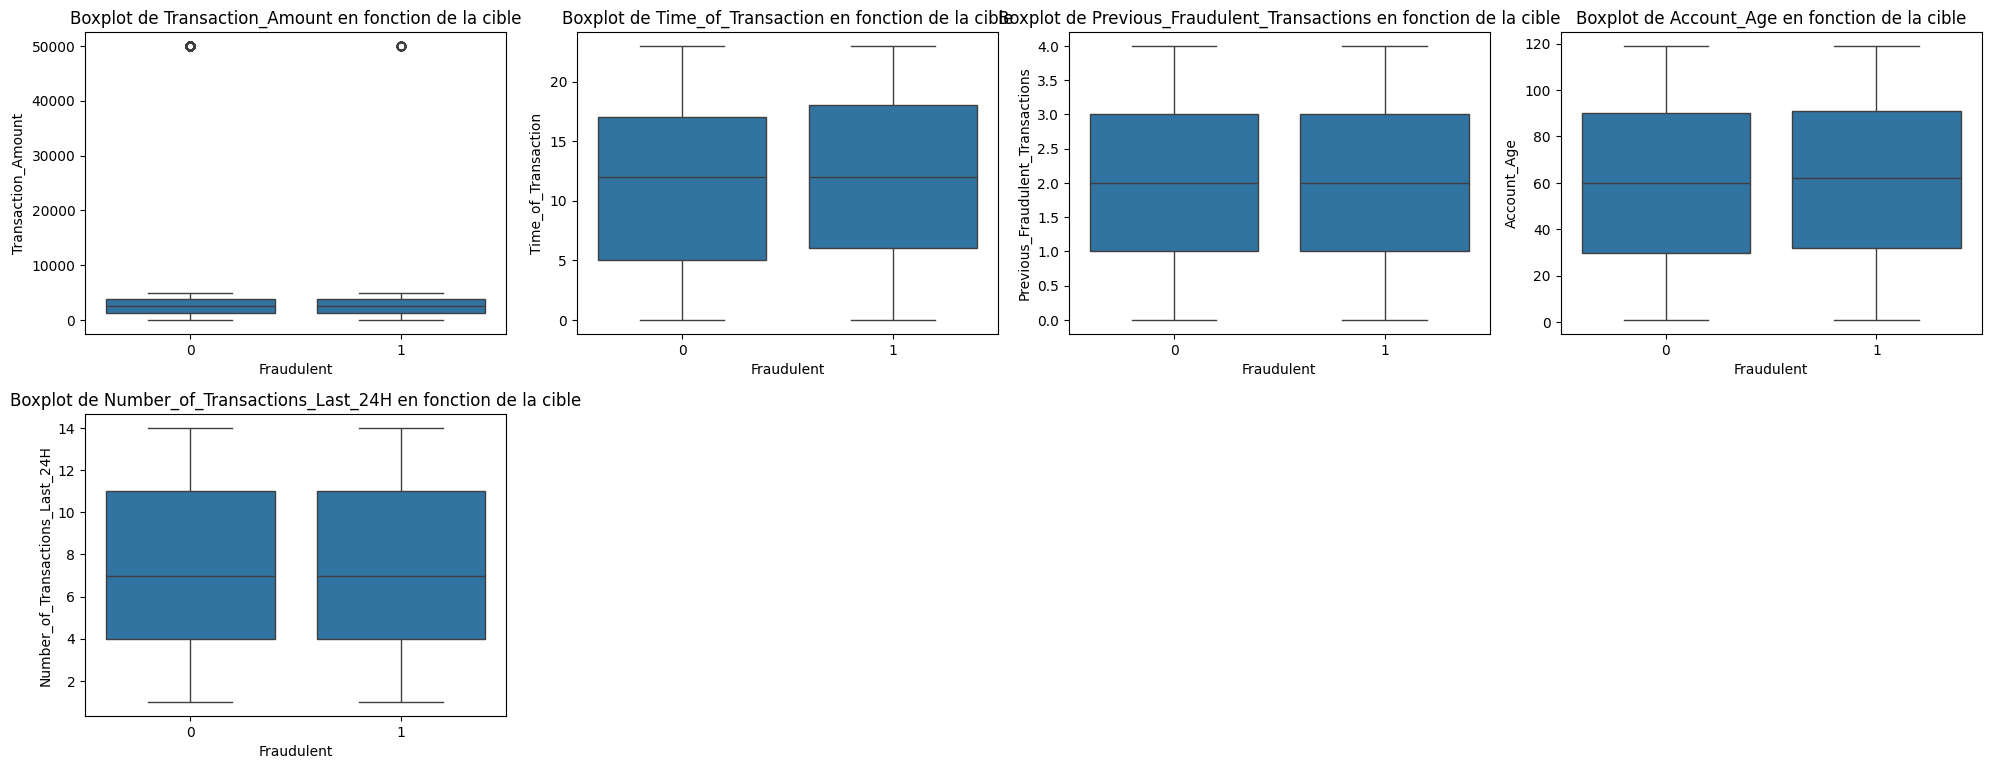

In [90]:
# analyse bivariée entre les variables numériques et la cible
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(x=df['Fraudulent'], y=df[col])
    plt.title(f'Boxplot de {col} en fonction de la cible')
plt.tight_layout()
plt.show()

> On observe que les boxplots se ressemble pour les deux classes de la clible, un modele simple n'arrivera peut être pas à distinguer les deux classes

## Correlations

La matrice de correlation permet d'examiner les relations lineaires entre variables numeriques et de voir si certaines colonnes evoluent ensemble.

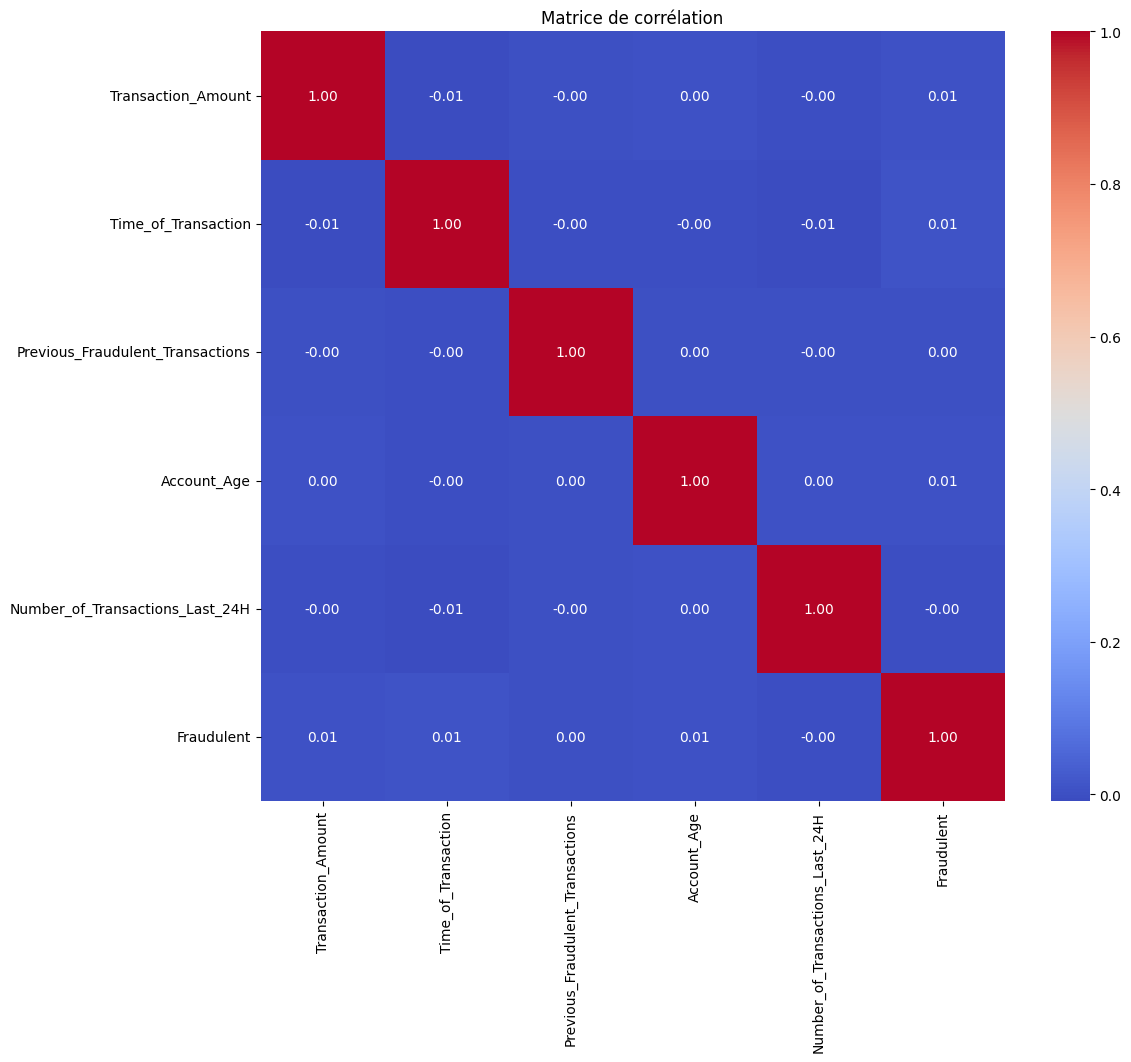

In [91]:
# matrice de corrélation entre les variables numériques et la cible
corr = df[num_cols + ['Fraudulent']].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation')
plt.show()

> Les correlations sont faibles. Cela signifie qu'il n'y a pas de relation lineaire forte entre les variables.

## Desequilibre des classes

Avant d'entrainer le modele, il est important de verifier la repartition de la cible, car un fort desequilibre peut biaiser l'evaluation.

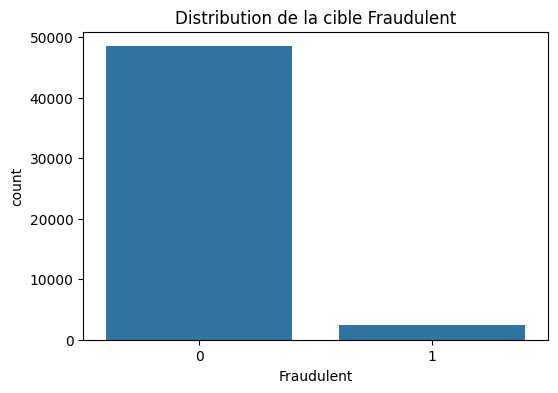

In [92]:
# distribution de la cible
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Fraudulent'])
plt.title('Distribution de la cible Fraudulent')
plt.show()

### Interpretation

La cible est fortement desequilibree. Cela implique deux consequences pratiques :
- il faut utiliser `stratify=y` lors de la separation train/test pour conserver des proportions comparables ;
- l'accuracy seule sera peu informative, donc il faut privilegier des metriques comme l'AUC, la precision, le rappel ou la matrice de confusion.

# 3. Nettoyage et prétraitement des données

> Dans cette section, on prepare les donnees pour l'apprentissage : suppression des doublons, traitement des valeurs manquantes, encodage des variables categorielles et creation de nouvelles variables.

## Gestion des doublons

La suppression des doublons evite de surrepresenter certaines observations et limite un eventuel biais dans l'apprentissage.

In [93]:
# supppresion des doublons
df = df.drop_duplicates()
print(f"Nombre de doublons après suppression : {df.duplicated().sum()}")
print(f"Taille du dataset après suppression des doublons : {df.shape[0]} lignes et {df.shape[1]} colonnes")

Nombre de doublons après suppression : 0
Taille du dataset après suppression des doublons : 50119 lignes et 12 colonnes


## Gestion des valeurs manquantes

On remplace ici les valeurs manquantes avec des regles simples et interpretable : la mediane pour le numerique et le mode pour le categoriel.

In [94]:
# Imputation des valeurs manquantes pour les variables catégorielles
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Imputation des valeurs manquantes pour les variables numériques
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


print("Vérification des valeurs manquantes après imputation :")
print(df.isnull().sum())

Vérification des valeurs manquantes après imputation :
Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64


## Encodage des variables categorielles

Les algorithmes de scikit-learn attendent des entrees numeriques. Il faut donc transformer les modalites textuelles en colonnes binaires.

In [95]:
print(cat_cols)

['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']


> Ces variables sont nominales, c'est-a-dire sans ordre naturel entre les modalites. Le one-hot encoding est donc un choix adapte pour ne pas introduire de hierarchie artificielle.

In [96]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.head()

,Transaction_ID,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent,Transaction_Type_Bank Transfer,Transaction_Type_Bill Payment,...,Location_Houston,Location_Los Angeles,Location_Miami,Location_New York,Location_San Francisco,Location_Seattle,Payment_Method_Debit Card,Payment_Method_Invalid Method,Payment_Method_Net Banking,Payment_Method_UPI
0,T1,4174,1292.76,16.0,0,119,13,0,False,False,...,False,False,False,False,True,False,True,False,False,False
1,T2,4507,1554.58,13.0,4,79,3,0,False,False,...,False,False,False,True,False,False,False,False,False,False
2,T3,1860,2395.02,12.0,3,115,9,0,False,False,...,False,False,False,False,False,False,False,False,False,True
3,T4,2294,100.10,15.0,4,3,4,0,False,True,...,False,False,False,False,False,False,False,False,False,True
4,T5,2130,1490.50,19.0,2,57,7,0,False,False,...,False,False,False,False,True,False,False,False,False,False


## Standardisation des variables numeriques

On met ici les variables numeriques sur une echelle comparable.

In [97]:
# Normalisation des variables numériques

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
df_encoded.head()

,Transaction_ID,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent,Transaction_Type_Bank Transfer,Transaction_Type_Bill Payment,...,Location_Houston,Location_Los Angeles,Location_Miami,Location_New York,Location_San Francisco,Location_Seattle,Payment_Method_Debit Card,Payment_Method_Invalid Method,Payment_Method_Net Banking,Payment_Method_UPI
0,T1,4174,-0.340960,0.664877,-1.410441,1.714659,1.369323,0,False,False,...,False,False,False,False,True,False,True,False,False,False
1,T2,4507,-0.287913,0.220229,1.415459,0.551605,-1.118384,0,False,False,...,False,False,False,True,False,False,False,False,False,False
2,T3,1860,-0.117633,0.072013,0.708984,1.598353,0.374241,0,False,False,...,False,False,False,False,False,False,False,False,False,True
3,T4,2294,-0.582603,0.516661,1.415459,-1.658197,-0.869613,0,False,True,...,False,False,False,False,False,False,False,False,False,True
4,T5,2130,-0.300896,1.109525,0.002509,-0.088074,-0.123301,0,False,False,...,False,False,False,False,True,False,False,False,False,False


## Feature engineering

On cree quelques variables derivees pour essayer de rendre plus explicites certains comportements potentiellement suspects, par exemple des rapports entre montant, anciennete du compte et activite recente.

In [98]:
# Calcul sur les valeurs originales (non normalisées) pour des ratios cohérents
df["amount_ratio"] = df["Transaction_Amount"] / df["Number_of_Transactions_Last_24H"]
df["fraud_ratio"] = df["Previous_Fraudulent_Transactions"] / df["Account_Age"]
df["montant_age_compte"] = df["Transaction_Amount"] / df["Account_Age"]

# Ajout à df_encoded
new_features = ["amount_ratio", "fraud_ratio", "montant_age_compte"]
for feat in new_features:
    df_encoded[feat] = df[feat]

# Normalisation des nouvelles features
df_encoded[new_features] = StandardScaler().fit_transform(df_encoded[new_features])

## Construction du jeu de variables

A cette etape, on separe les variables explicatives `X` de la cible `y`, puis on retire les identifiants.

In [99]:
X = df_encoded.drop(columns=["Transaction_ID", "User_ID", "Fraudulent"])
y = df_encoded['Fraudulent']

## Decoupage en jeux d'entrainement et de test

On separe ensuite les donnees pour pouvoir entrainer le modele sur un sous-ensemble et mesurer sa capacite de generalisation sur des observations non vues.

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Pour dessiner les metriques d'évaluation

def plot_auc_and_confusion(model, X_eval, y_eval, model_name):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    auc_score = roc_auc_score(y_eval, y_proba)
    fpr, tpr, _ = roc_curve(y_eval, y_proba)
    cm = confusion_matrix(y_eval, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(fpr, tpr, label=f'AUC = {auc_score:.4f}', color='darkorange', linewidth=2)
    axes[0].plot([0, 1], [0, 1], linestyle='--', color='navy')
    axes[0].set_title(f'Courbe ROC - {model_name}')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].legend(loc='lower right')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
    axes[1].set_title(f'Matrice de confusion - {model_name}')
    axes[1].set_xlabel('Prediction')
    axes[1].set_ylabel('Reel')
    axes[1].set_xticklabels(['Non fraude', 'Fraude'])
    axes[1].set_yticklabels(['Non fraude', 'Fraude'])

    plt.tight_layout()
    plt.show()
    print(f'AUC score {model_name} : {auc_score:.4f}')
    return auc_score

def draw_tree_model(model, feature_names, model_name, max_depth=3):
    plt.figure(figsize=(24, 12))
    plot_tree(
        model,
        feature_names=feature_names,
        class_names=['Non fraude', 'Fraude'],
        filled=True,
        rounded=True,
        max_depth=max_depth,
        fontsize=8
    )
    plt.title(f"Visualisation de l'arbre - {model_name} (profondeur affichee = {max_depth})")
    plt.show()

# 4. Le modèle de base
> Cette premiere version sert de point de comparaison. elle donne une reference utile avant de chercher a ajuster les hyperparametres.

In [102]:
# random_state pour la reproductibilité
baseline_simple = DecisionTreeClassifier(random_state=42)

In [103]:
# Entrainement du model
baseline_simple.fit(X_train, y_train)

# prediction sur le test
y_pred_proba_baseline = baseline_simple.predict_proba(X_test)[:, 1]
y_pred_proba_baseline

array([0., 1., 1., ..., 1., 0., 0.], shape=(10024,))

AUC score baseline : 0.4997


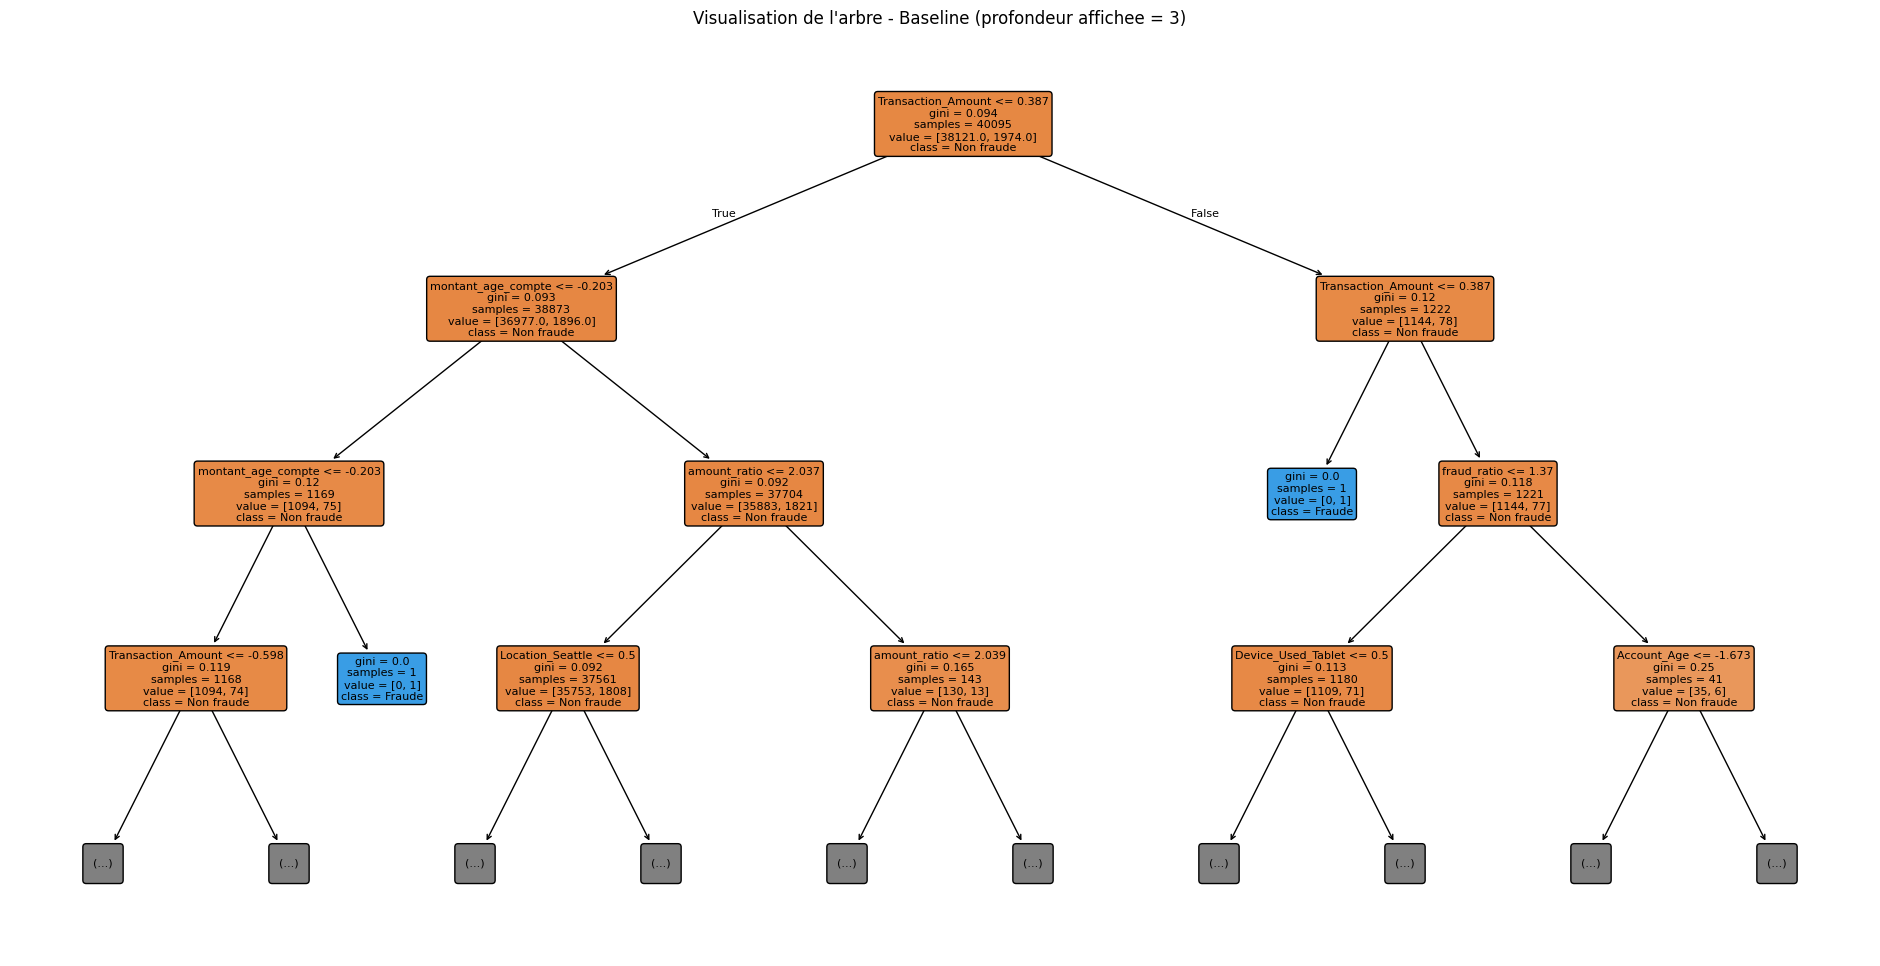

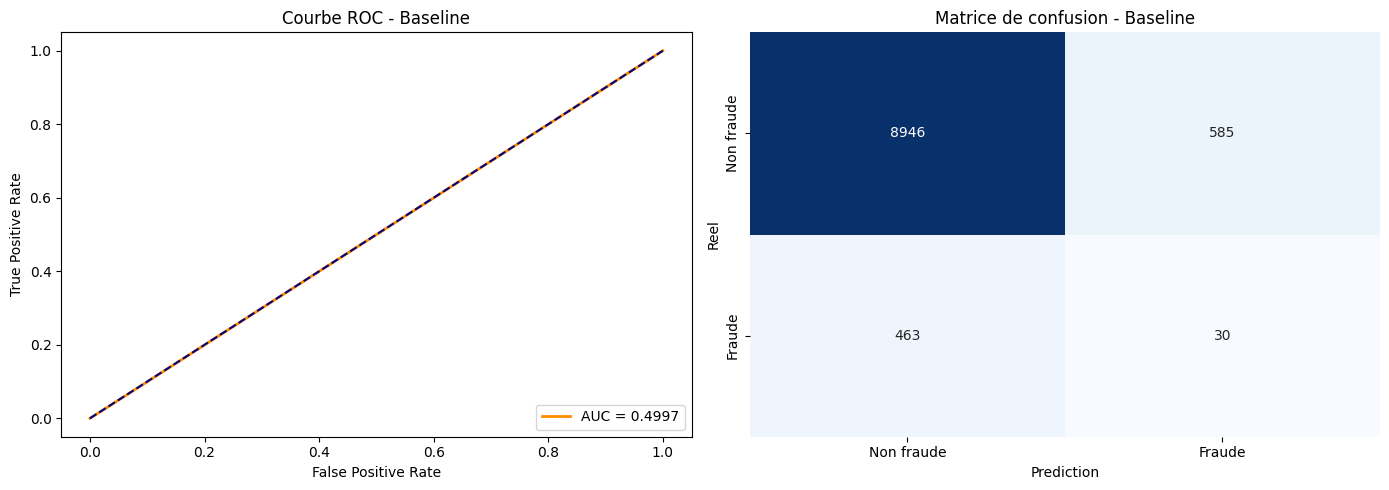

AUC score Baseline : 0.4997


0.49973663393265877

In [104]:
# Evaluation du model
auc_baseline = roc_auc_score(y_test, y_pred_proba_baseline)
print(f"AUC score baseline : {auc_baseline:.4f}")
draw_tree_model(baseline_simple, X_train.columns, "Baseline", max_depth=3)
plot_auc_and_confusion(baseline_simple, X_test, y_test, "Baseline")

> L'AUC obtenue est tres proche de 0.5, ce qui suggere que ce modele de base distingue mal les transactions frauduleuses des transactions non frauduleuses. ce qui confirme mon hypothèse lors de l'analyse des boxplots.
On va  tester si un reequilibrage des classes et un meilleur reglage de l'arbre peuvent ameliorer la situation.

In [105]:
# random_state pour la reproductibilité
baseline_balanced = DecisionTreeClassifier(random_state=42, class_weight='balanced')

In [106]:
# Entrainement du model
baseline_balanced.fit(X_train, y_train)

# prediction sur le test
y_pred_proba_balanced = baseline_balanced.predict_proba(X_test)[:, 1]
y_pred_proba_balanced

array([0., 0., 0., ..., 0., 0., 0.], shape=(10024,))

AUC score baseline (class_weight='balanced') : 0.5024


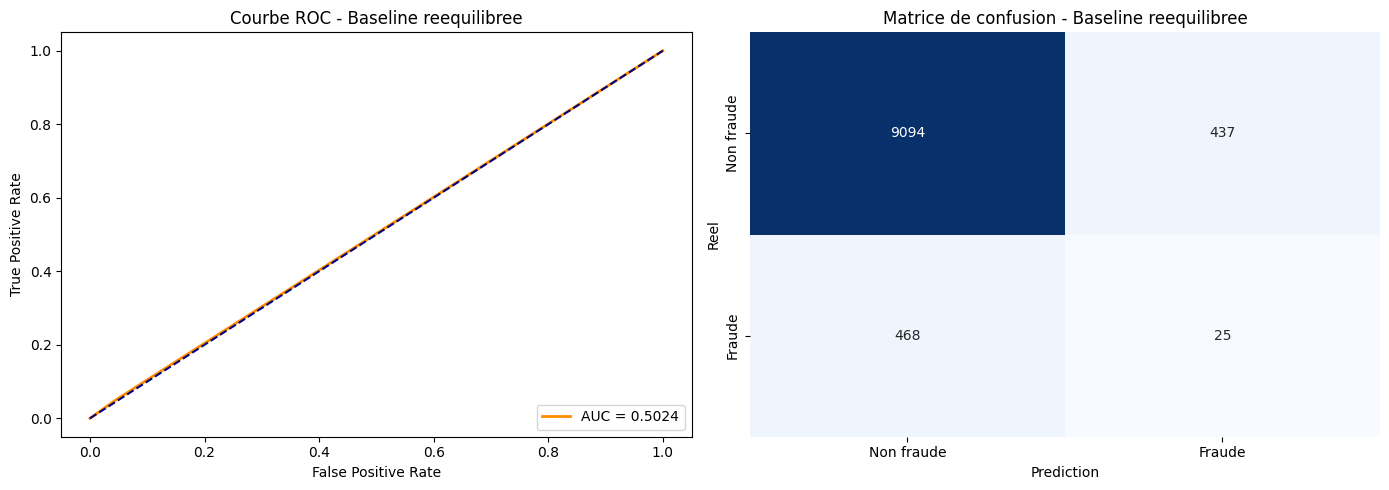

AUC score Baseline reequilibree : 0.5024


0.5024297780936042

In [107]:
auc_baseline_balanced = roc_auc_score(y_test, y_pred_proba_balanced)
print(f"AUC score baseline (class_weight='balanced') : {auc_baseline_balanced:.4f}")
plot_auc_and_confusion(baseline_balanced, X_test, y_test, "Baseline reequilibree")

Le modele de base etant peu performant, on passe maintenant a une phase d'optimisation pour chercher une meilleure combinaison d'hyperparametres.

# 5. Optimisation des hyperparametres

L'objectif ici est d'explorer plusieurs structures d'arbres afin d'identifier un compromis plus interessant entre biais, variance et prise en compte du desequilibre.

## Utilisation de RandomizedSearchCV

Plutot que de tester exhaustivement toutes les combinaisons possibles, on echantillonne un certain nombre de configurations de maniere aleatoire pour gagner du temps de calcul.

In [108]:
# Grille de paramètres à tester avec Randomized.
params_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "splitter": ["best", "random"],
    "max_depth": [3, 5, 7, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20, 50],
    "max_features": [None, "sqrt", "log2"],
    "class_weight": ["balanced", None],
    "random_state": [42]
}

In [109]:
n_entrainement = 1
for param in params_grid:
    n_entrainement *= len(params_grid[param])

print(f"Avec GridSearchCV on aura: {n_entrainement} entrainement fois le nombre de fold defini")

Avec GridSearchCV on aura: 5040 entrainement fois le nombre de fold defini


> Ici, on fixe `n_iter = 200`, ce qui permet d'explorer une partie representative de l'espace des hyperparametres sans supporter le cout d'une recherche exhaustive.

In [110]:
model = DecisionTreeClassifier()

random_grid = RandomizedSearchCV(estimator=model, param_distributions=params_grid, n_iter=200, cv=5, scoring='roc_auc', n_jobs=-1, verbose=2)

random_grid.fit(X_train, y_train)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


[CV] END class_weight=balanced, criterion=gini, max_depth=7, max_features=None, min_samples_leaf=50, min_samples_split=20, random_state=42, splitter=random; total time=   0.4s
[CV] END class_weight=balanced, criterion=gini, max_depth=7, max_features=None, min_samples_leaf=50, min_samples_split=20, random_state=42, splitter=random; total time=   0.1s
[CV] END class_weight=balanced, criterion=log_loss, max_depth=None, max_features=None, min_samples_leaf=5, min_samples_split=2, random_state=42, splitter=random; total time=   0.3s
[CV] END class_weight=balanced, criterion=log_loss, max_depth=None, max_features=None, min_samples_leaf=5, min_samples_split=2, random_state=42, splitter=random; total time=   0.2s
[CV] END class_weight=balanced, criterion=log_loss, max_depth=None, max_features=None, min_samples_leaf=5, min_samples_split=2, random_state=42, splitter=random; total time=   0.7s
[CV] END class_weight=balanced, criterion=log_loss, max_depth=10, max_features=None, min_samples_leaf=1, 

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', None], 'criterion': ['gini', 'entropy', ...], 'max_depth': [3, 5, ...], 'max_features': [None, 'sqrt', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",200
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be use

Meilleurs paramètres : {'splitter': 'random', 'random_state': 42, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 7, 'criterion': 'entropy', 'class_weight': 'balanced'}
AUC : 0.5025


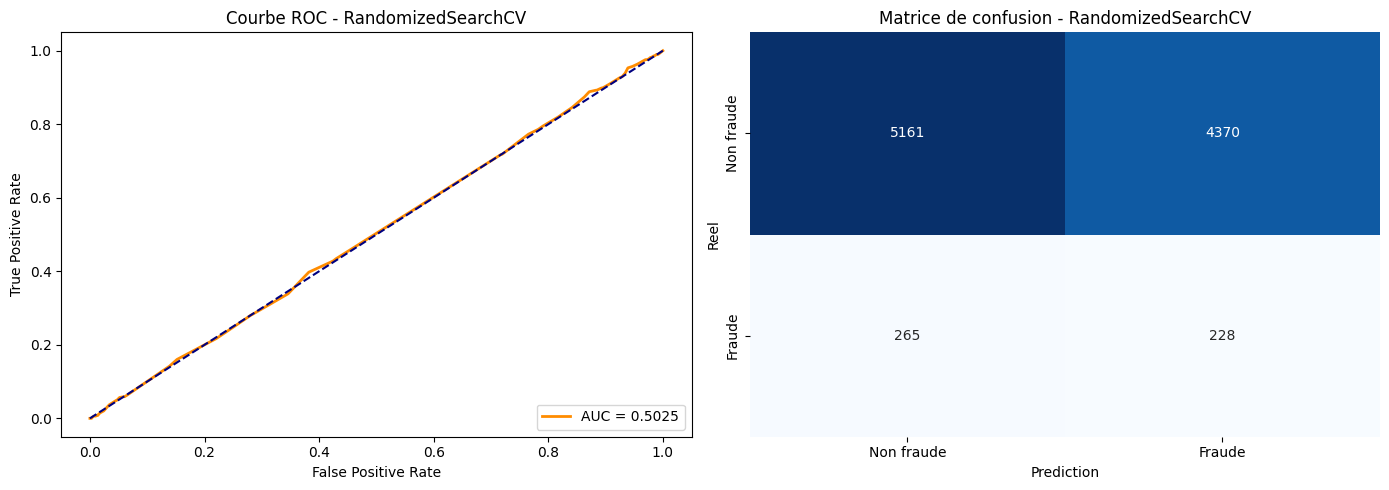

AUC score RandomizedSearchCV : 0.5025


0.5025497027634602

In [111]:
y_pred_proba_randomized = random_grid.predict_proba(X_test)[:, 1]
auc_randomized = roc_auc_score(y_test, y_pred_proba_randomized)

print(f"Meilleurs paramètres : {random_grid.best_params_}")
print(f"AUC : {auc_randomized:.4f}")
plot_auc_and_confusion(random_grid.best_estimator_, X_test, y_test, "RandomizedSearchCV")

### Utilisation d'Optuna

On teste aussi une approche d'optimisation bayesienne avec Optuna, qui peut orienter la recherche vers les zones les plus prometteuses de l'espace des hyperparametres.

In [112]:
# Fonction objectif pour Optuna : on maximise le AUC sur le jeu de test.
def objective(trial):
    params = {
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "splitter": trial.suggest_categorical("splitter", ["best", "random"]),
        "max_depth": trial.suggest_categorical("max_depth", [3, 5, 7, 10, 15, 20, None]),
        "min_samples_split": trial.suggest_categorical("min_samples_split", [2, 5, 10, 20]),
        "min_samples_leaf": trial.suggest_categorical("min_samples_leaf", [1, 5, 10, 20, 50]),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", None]),
    }

    tree_model = DecisionTreeClassifier(**params)
    tree_model.fit(X_train, y_train)
    y_proba = tree_model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)

    return auc

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=100, show_progress_bar=True)

optuna_best_params = study.best_params
optuna_best_cv_auc = study.best_value

[I 2026-04-27 19:17:08,462] A new study created in memory with name: no-name-50d544c2-d5fa-474e-a52c-59029f23ce55
Best trial: 0. Best value: 0.508873:   1%|          | 1/100 [00:00<00:18,  5.41it/s]

[I 2026-04-27 19:17:08,646] Trial 0 finished with value: 0.5088733614640217 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 50, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.5088733614640217.
[I 2026-04-27 19:17:08,726] Trial 1 finished with value: 0.5022983610862642 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.5088733614640217.


Best trial: 2. Best value: 0.515348:   4%|▍         | 4/100 [00:01<00:26,  3.65it/s]

[I 2026-04-27 19:17:09,435] Trial 2 finished with value: 0.5153484423519877 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.5153484423519877.
[I 2026-04-27 19:17:09,585] Trial 3 finished with value: 0.4845970754554957 and parameters: {'criterion': 'log_loss', 'splitter': 'best', 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': None}. Best is trial 2 with value: 0.5153484423519877.


Best trial: 2. Best value: 0.515348:   6%|▌         | 6/100 [00:01<00:16,  5.59it/s]

[I 2026-04-27 19:17:09,679] Trial 4 finished with value: 0.4897494734274811 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': None}. Best is trial 2 with value: 0.5153484423519877.
[I 2026-04-27 19:17:09,749] Trial 5 finished with value: 0.4975260615355084 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 50, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.5153484423519877.


Best trial: 2. Best value: 0.515348:   8%|▊         | 8/100 [00:01<00:16,  5.46it/s]

[I 2026-04-27 19:17:09,927] Trial 6 finished with value: 0.4889143635703117 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 10, 'min_samples_leaf': 50, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.5153484423519877.
[I 2026-04-27 19:17:10,124] Trial 7 finished with value: 0.49851312563274364 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': None}. Best is trial 2 with value: 0.5153484423519877.


Best trial: 2. Best value: 0.515348:   9%|▉         | 9/100 [00:01<00:16,  5.43it/s]

[I 2026-04-27 19:17:10,311] Trial 8 finished with value: 0.504964902614145 and parameters: {'criterion': 'log_loss', 'splitter': 'best', 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.5153484423519877.
[I 2026-04-27 19:17:10,396] Trial 9 finished with value: 0.5092891074135579 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 2 with value: 0.5153484423519877.


Best trial: 11. Best value: 0.518911:  12%|█▏        | 12/100 [00:02<00:12,  6.96it/s]

[I 2026-04-27 19:17:10,549] Trial 10 finished with value: 0.505304565033116 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 3, 'min_samples_split': 20, 'min_samples_leaf': 20, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.5153484423519877.
[I 2026-04-27 19:17:10,656] Trial 11 finished with value: 0.5189106413298933 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.
[I 2026-04-27 19:17:10,731] Trial 12 finished with value: 0.5035172937332922 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.


Best trial: 11. Best value: 0.518911:  14%|█▍        | 14/100 [00:02<00:10,  8.42it/s]

[I 2026-04-27 19:17:10,821] Trial 13 finished with value: 0.5095102284995923 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.


Best trial: 11. Best value: 0.518911:  16%|█▌        | 16/100 [00:02<00:14,  5.98it/s]

[I 2026-04-27 19:17:11,164] Trial 14 finished with value: 0.5075458900740895 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 20, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.
[I 2026-04-27 19:17:11,324] Trial 15 finished with value: 0.49785242263794693 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.


Best trial: 11. Best value: 0.518911:  16%|█▌        | 16/100 [00:02<00:14,  5.98it/s]

[I 2026-04-27 19:17:11,415] Trial 16 finished with value: 0.49978909432506247 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.


Best trial: 11. Best value: 0.518911:  18%|█▊        | 18/100 [00:03<00:14,  5.63it/s]

[I 2026-04-27 19:17:11,707] Trial 17 finished with value: 0.5023945562074265 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.


Best trial: 11. Best value: 0.518911:  19%|█▉        | 19/100 [00:04<00:25,  3.20it/s]

[I 2026-04-27 19:17:12,482] Trial 18 finished with value: 0.5009035318294119 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': None, 'class_weight': None}. Best is trial 11 with value: 0.5189106413298933.
[I 2026-04-27 19:17:12,581] Trial 19 finished with value: 0.48835294160211273 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 20, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.


Best trial: 11. Best value: 0.518911:  21%|██        | 21/100 [00:04<00:26,  2.93it/s]

[I 2026-04-27 19:17:13,253] Trial 20 finished with value: 0.5109030359563317 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.


Best trial: 11. Best value: 0.518911:  22%|██▏       | 22/100 [00:05<00:34,  2.28it/s]

[I 2026-04-27 19:17:14,035] Trial 21 finished with value: 0.5081715840037728 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.


Best trial: 11. Best value: 0.518911:  23%|██▎       | 23/100 [00:06<00:37,  2.05it/s]

[I 2026-04-27 19:17:14,684] Trial 22 finished with value: 0.5086477711356323 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.


Best trial: 11. Best value: 0.518911:  24%|██▍       | 24/100 [00:07<00:42,  1.77it/s]

[I 2026-04-27 19:17:15,476] Trial 23 finished with value: 0.5089934989549422 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.


Best trial: 11. Best value: 0.518911:  25%|██▌       | 25/100 [00:07<00:37,  2.00it/s]

[I 2026-04-27 19:17:15,792] Trial 24 finished with value: 0.5014784679352079 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 7, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.


Best trial: 11. Best value: 0.518911:  26%|██▌       | 26/100 [00:08<00:44,  1.65it/s]

[I 2026-04-27 19:17:16,681] Trial 25 finished with value: 0.5061931993880118 and parameters: {'criterion': 'entropy', 'splitter': 'best', 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.
[I 2026-04-27 19:17:16,732] Trial 26 finished with value: 0.5104792028063437 and parameters: {'criterion': 'gini', 'splitter': 'random', 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': None, 'class_weight': None}. Best is trial 11 with value: 0.5189106413298933.


Best trial: 11. Best value: 0.518911:  30%|███       | 30/100 [00:08<00:18,  3.77it/s]

[I 2026-04-27 19:17:16,950] Trial 27 finished with value: 0.48958400504981814 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.
[I 2026-04-27 19:17:17,005] Trial 28 finished with value: 0.5159503003224453 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.
[I 2026-04-27 19:17:17,057] Trial 29 finished with value: 0.5074667206380886 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': None}. Best is trial 11 with value: 0.5189106413298933.
[I 2026-04-27 19:17:17,133] Trial 30 finished with value: 0.5138755077644572 and parameters

Best trial: 11. Best value: 0.518911:  34%|███▍      | 34/100 [00:08<00:10,  6.07it/s]

[I 2026-04-27 19:17:17,215] Trial 31 finished with value: 0.5047404828016105 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.
[I 2026-04-27 19:17:17,307] Trial 32 finished with value: 0.4914201187839489 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.
[I 2026-04-27 19:17:17,409] Trial 33 finished with value: 0.5054492833569882 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.


Best trial: 11. Best value: 0.518911:  38%|███▊      | 38/100 [00:09<00:06,  9.32it/s]

[I 2026-04-27 19:17:17,487] Trial 34 finished with value: 0.516155991881302 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.
[I 2026-04-27 19:17:17,529] Trial 35 finished with value: 0.5036961698380197 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 50, 'max_features': 'log2', 'class_weight': None}. Best is trial 11 with value: 0.5189106413298933.
[I 2026-04-27 19:17:17,581] Trial 36 finished with value: 0.49636086620727105 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.
[I 2026-04-27 19:17:17,644] Trial 37 finished with value: 0.5099460860397256 and 

Best trial: 40. Best value: 0.524176:  40%|████      | 40/100 [00:09<00:05, 10.84it/s]

[I 2026-04-27 19:17:17,698] Trial 38 finished with value: 0.5061079645516722 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': None, 'min_samples_split': 20, 'min_samples_leaf': 50, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 11 with value: 0.5189106413298933.
[I 2026-04-27 19:17:17,761] Trial 39 finished with value: 0.48686138517143696 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 11 with value: 0.5189106413298933.
[I 2026-04-27 19:17:17,849] Trial 40 finished with value: 0.5241757280555411 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.


Best trial: 40. Best value: 0.524176:  42%|████▏     | 42/100 [00:09<00:05, 10.64it/s]

[I 2026-04-27 19:17:17,952] Trial 41 finished with value: 0.5124112988405721 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:18,084] Trial 42 finished with value: 0.5193753361242688 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.


Best trial: 40. Best value: 0.524176:  46%|████▌     | 46/100 [00:09<00:05, 10.36it/s]

[I 2026-04-27 19:17:18,183] Trial 43 finished with value: 0.513328344807581 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:18,274] Trial 44 finished with value: 0.5237609398007953 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:18,360] Trial 45 finished with value: 0.49891588949734433 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.


Best trial: 40. Best value: 0.524176:  50%|█████     | 50/100 [00:10<00:04, 12.06it/s]

[I 2026-04-27 19:17:18,452] Trial 46 finished with value: 0.5013658855920778 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:18,519] Trial 47 finished with value: 0.5145812224143996 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:18,583] Trial 48 finished with value: 0.49197387919382535 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:18,646] Trial 49 finished with value: 0.5032542468975478 a

Best trial: 40. Best value: 0.524176:  54%|█████▍    | 54/100 [00:10<00:03, 13.35it/s]

[I 2026-04-27 19:17:18,719] Trial 50 finished with value: 0.49593830998367033 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:18,783] Trial 51 finished with value: 0.5056646582742809 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:18,852] Trial 52 finished with value: 0.5120260927137942 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:18,916] Trial 53 finished with value: 0.49304607171686804 and p

Best trial: 40. Best value: 0.524176:  58%|█████▊    | 58/100 [00:10<00:02, 15.33it/s]

[I 2026-04-27 19:17:18,973] Trial 54 finished with value: 0.5122711561695868 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:19,017] Trial 55 finished with value: 0.503674887731568 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 50, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:19,070] Trial 56 finished with value: 0.4927789812808976 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:19,137] Trial 57 finished with value: 0.4984713062935658 and p

Best trial: 40. Best value: 0.524176:  62%|██████▏   | 62/100 [00:10<00:02, 15.49it/s]

[I 2026-04-27 19:17:19,213] Trial 58 finished with value: 0.5062452341382865 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:19,267] Trial 59 finished with value: 0.5183996579539851 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:19,341] Trial 60 finished with value: 0.4995426475323504 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:19,393] Trial 61 finished with value: 0.4839896841373606 

Best trial: 40. Best value: 0.524176:  65%|██████▌   | 65/100 [00:11<00:02, 16.80it/s]

[I 2026-04-27 19:17:19,446] Trial 62 finished with value: 0.49595501643723483 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:19,494] Trial 63 finished with value: 0.49461807450993156 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:19,548] Trial 64 finished with value: 0.5045903375405929 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:19,599] Trial 65 finished with value: 0.505623264577232 a

Best trial: 40. Best value: 0.524176:  70%|███████   | 70/100 [00:11<00:01, 17.67it/s]

[I 2026-04-27 19:17:19,676] Trial 66 finished with value: 0.4981233438530786 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:19,714] Trial 67 finished with value: 0.5089004961497476 and parameters: {'criterion': 'entropy', 'splitter': 'random', 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 20, 'max_features': 'log2', 'class_weight': None}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:19,759] Trial 68 finished with value: 0.5087398162460365 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 50, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.
[I 2026-04-27 19:17:19,825] Trial 69 finished with value: 0.4862594207904472 and para

Best trial: 40. Best value: 0.524176:  70%|███████   | 70/100 [00:11<00:01, 17.67it/s]

[I 2026-04-27 19:17:20,040] Trial 70 finished with value: 0.5013453483593517 and parameters: {'criterion': 'log_loss', 'splitter': 'random', 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.


Best trial: 40. Best value: 0.524176:  72%|███████▏  | 72/100 [00:12<00:04,  6.22it/s]

[I 2026-04-27 19:17:20,740] Trial 71 finished with value: 0.5158183512624439 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.


Best trial: 40. Best value: 0.524176:  72%|███████▏  | 72/100 [00:12<00:04,  6.22it/s]

[I 2026-04-27 19:17:21,373] Trial 72 finished with value: 0.5171399700731019 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.


Best trial: 40. Best value: 0.524176:  74%|███████▍  | 74/100 [00:13<00:07,  3.44it/s]

[I 2026-04-27 19:17:22,025] Trial 73 finished with value: 0.514838097439273 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.


Best trial: 40. Best value: 0.524176:  75%|███████▌  | 75/100 [00:14<00:08,  2.99it/s]

[I 2026-04-27 19:17:22,582] Trial 74 finished with value: 0.520705680598572 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.


Best trial: 40. Best value: 0.524176:  76%|███████▌  | 76/100 [00:14<00:08,  2.69it/s]

[I 2026-04-27 19:17:23,114] Trial 75 finished with value: 0.5193740591978816 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.


Best trial: 40. Best value: 0.524176:  77%|███████▋  | 77/100 [00:15<00:09,  2.43it/s]

[I 2026-04-27 19:17:23,676] Trial 76 finished with value: 0.5238894837237642 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.


Best trial: 40. Best value: 0.524176:  78%|███████▊  | 78/100 [00:15<00:09,  2.24it/s]

[I 2026-04-27 19:17:24,234] Trial 77 finished with value: 0.5225161493944284 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 40 with value: 0.5241757280555411.


Best trial: 40. Best value: 0.524176:  79%|███████▉  | 79/100 [00:16<00:11,  1.85it/s]

[I 2026-04-27 19:17:25,060] Trial 78 finished with value: 0.483414428799968 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': None}. Best is trial 40 with value: 0.5241757280555411.


Best trial: 79. Best value: 0.524689:  80%|████████  | 80/100 [00:17<00:10,  1.86it/s]

[I 2026-04-27 19:17:25,594] Trial 79 finished with value: 0.5246889460526268 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 79 with value: 0.5246889460526268.


Best trial: 79. Best value: 0.524689:  81%|████████  | 81/100 [00:17<00:10,  1.83it/s]

[I 2026-04-27 19:17:26,165] Trial 80 finished with value: 0.5242388295011708 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 79 with value: 0.5246889460526268.


Best trial: 79. Best value: 0.524689:  82%|████████▏ | 82/100 [00:18<00:09,  1.83it/s]

[I 2026-04-27 19:17:26,706] Trial 81 finished with value: 0.5225023160252347 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 79 with value: 0.5246889460526268.


Best trial: 82. Best value: 0.526235:  83%|████████▎ | 83/100 [00:18<00:09,  1.82it/s]

[I 2026-04-27 19:17:27,262] Trial 82 finished with value: 0.5262347718547548 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 82 with value: 0.5262347718547548.


Best trial: 82. Best value: 0.526235:  84%|████████▍ | 84/100 [00:19<00:08,  1.83it/s]

[I 2026-04-27 19:17:27,804] Trial 83 finished with value: 0.5245373110441576 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 82 with value: 0.5262347718547548.


Best trial: 82. Best value: 0.526235:  85%|████████▌ | 85/100 [00:19<00:08,  1.84it/s]

[I 2026-04-27 19:17:28,337] Trial 84 finished with value: 0.5227720667245116 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 82 with value: 0.5262347718547548.


Best trial: 82. Best value: 0.526235:  86%|████████▌ | 86/100 [00:20<00:07,  1.88it/s]

[I 2026-04-27 19:17:28,843] Trial 85 finished with value: 0.524589665026029 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 82 with value: 0.5262347718547548.


Best trial: 82. Best value: 0.526235:  87%|████████▋ | 87/100 [00:20<00:07,  1.83it/s]

[I 2026-04-27 19:17:29,426] Trial 86 finished with value: 0.526068132961237 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 82 with value: 0.5262347718547548.


Best trial: 87. Best value: 0.526558:  88%|████████▊ | 88/100 [00:21<00:06,  1.82it/s]

[I 2026-04-27 19:17:29,978] Trial 87 finished with value: 0.5265580470517579 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 87 with value: 0.5265580470517579.


Best trial: 87. Best value: 0.526558:  89%|████████▉ | 89/100 [00:22<00:06,  1.62it/s]

[I 2026-04-27 19:17:30,759] Trial 88 finished with value: 0.5258727632240093 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 87 with value: 0.5265580470517579.


Best trial: 87. Best value: 0.526558:  90%|█████████ | 90/100 [00:22<00:06,  1.61it/s]

[I 2026-04-27 19:17:31,386] Trial 89 finished with value: 0.5229577531033036 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 87 with value: 0.5265580470517579.


Best trial: 87. Best value: 0.526558:  91%|█████████ | 91/100 [00:23<00:05,  1.59it/s]

[I 2026-04-27 19:17:32,034] Trial 90 finished with value: 0.526115804879689 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 87 with value: 0.5265580470517579.


Best trial: 87. Best value: 0.526558:  92%|█████████▏| 92/100 [00:24<00:04,  1.62it/s]

[I 2026-04-27 19:17:32,621] Trial 91 finished with value: 0.5228466605076251 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 87 with value: 0.5265580470517579.


Best trial: 87. Best value: 0.526558:  93%|█████████▎| 93/100 [00:24<00:04,  1.68it/s]

[I 2026-04-27 19:17:33,166] Trial 92 finished with value: 0.5264971802273057 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 87 with value: 0.5265580470517579.


Best trial: 87. Best value: 0.526558:  94%|█████████▍| 94/100 [00:25<00:03,  1.74it/s]

[I 2026-04-27 19:17:33,691] Trial 93 finished with value: 0.5244057876262854 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 87 with value: 0.5265580470517579.


Best trial: 87. Best value: 0.526558:  95%|█████████▌| 95/100 [00:25<00:02,  1.68it/s]

[I 2026-04-27 19:17:34,331] Trial 94 finished with value: 0.52447995576727 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 87 with value: 0.5265580470517579.


Best trial: 87. Best value: 0.526558:  96%|█████████▌| 96/100 [00:26<00:02,  1.72it/s]

[I 2026-04-27 19:17:34,890] Trial 95 finished with value: 0.5245647649614804 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 87 with value: 0.5265580470517579.


Best trial: 87. Best value: 0.526558:  97%|█████████▋| 97/100 [00:27<00:01,  1.72it/s]

[I 2026-04-27 19:17:35,468] Trial 96 finished with value: 0.5244699531772377 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 87 with value: 0.5265580470517579.


Best trial: 87. Best value: 0.526558:  98%|█████████▊| 98/100 [00:27<00:01,  1.74it/s]

[I 2026-04-27 19:17:36,021] Trial 97 finished with value: 0.48329280156159593 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': None}. Best is trial 87 with value: 0.5265580470517579.


Best trial: 87. Best value: 0.526558:  99%|█████████▉| 99/100 [00:28<00:00,  1.70it/s]

[I 2026-04-27 19:17:36,643] Trial 98 finished with value: 0.5249294338555324 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 87 with value: 0.5265580470517579.


Best trial: 87. Best value: 0.526558: 100%|██████████| 100/100 [00:28<00:00,  3.47it/s]

[I 2026-04-27 19:17:37,314] Trial 99 finished with value: 0.526079306067124 and parameters: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}. Best is trial 87 with value: 0.5265580470517579.


Meilleurs parametres Optuna:
{'criterion': 'gini', 'splitter': 'best', 'max_depth': 15, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': 'balanced'}
Meilleure AUC CV: 0.5266
AUC sur le jeu de test : 0.5260


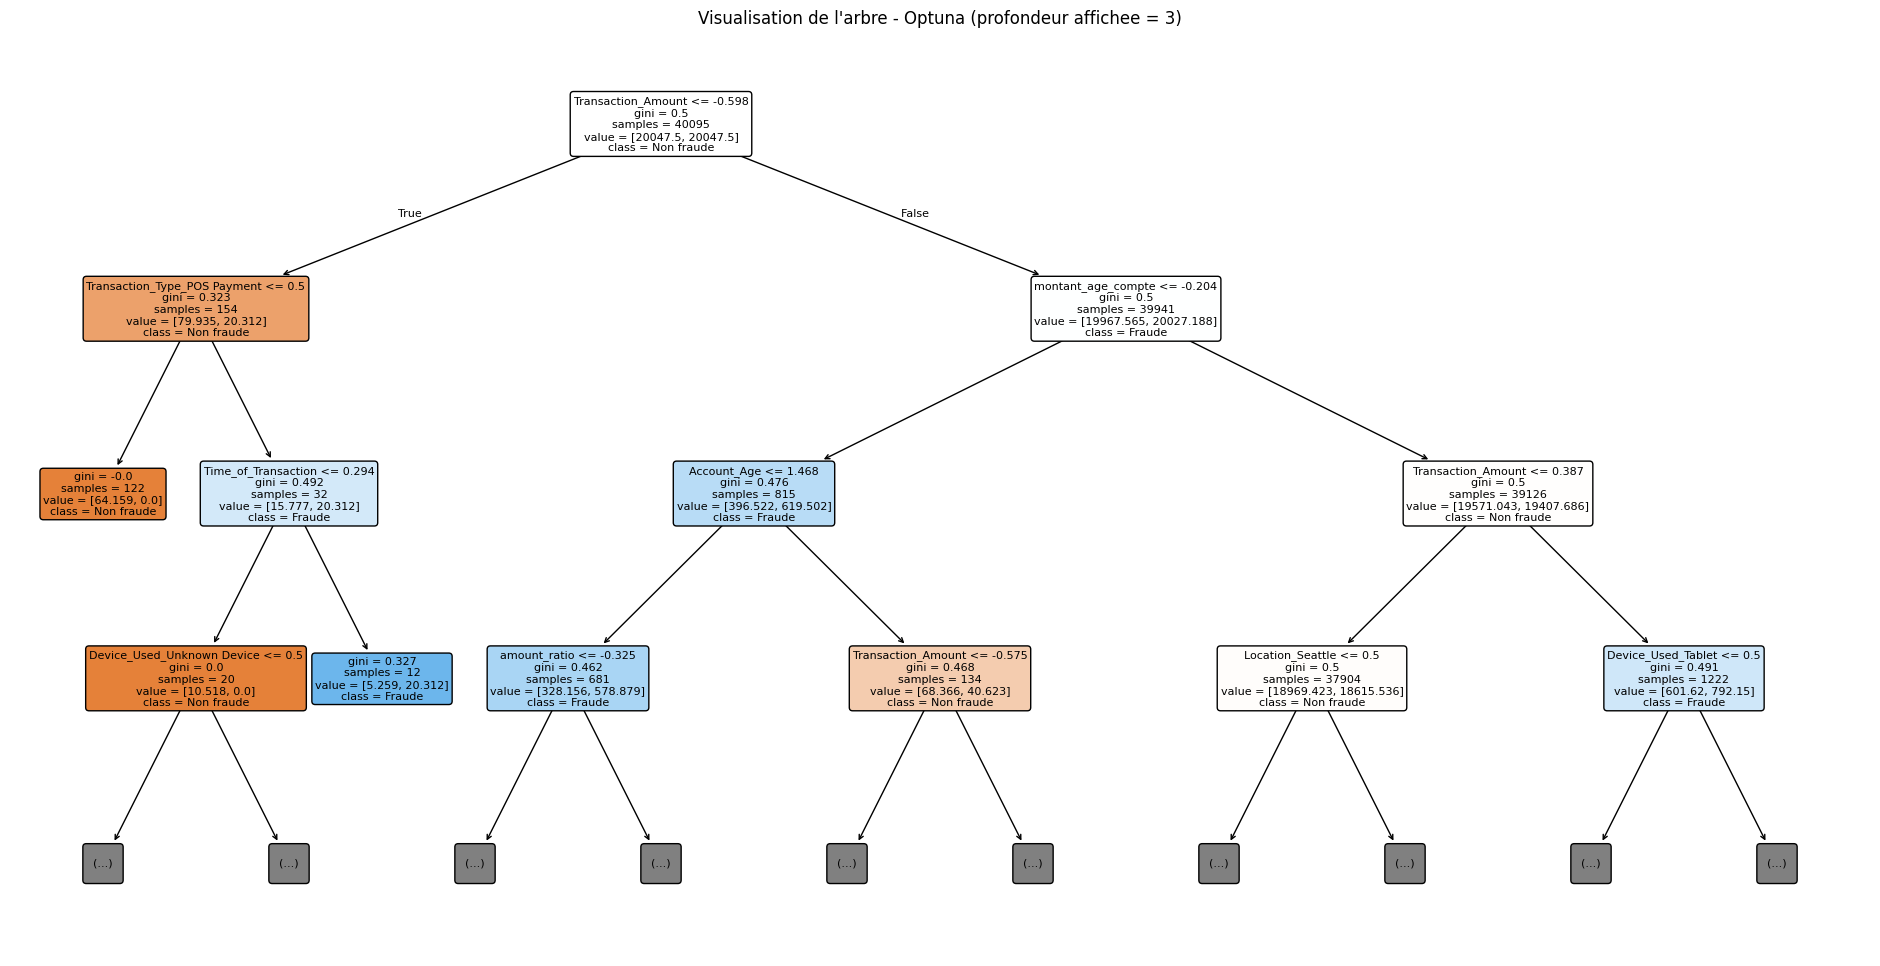

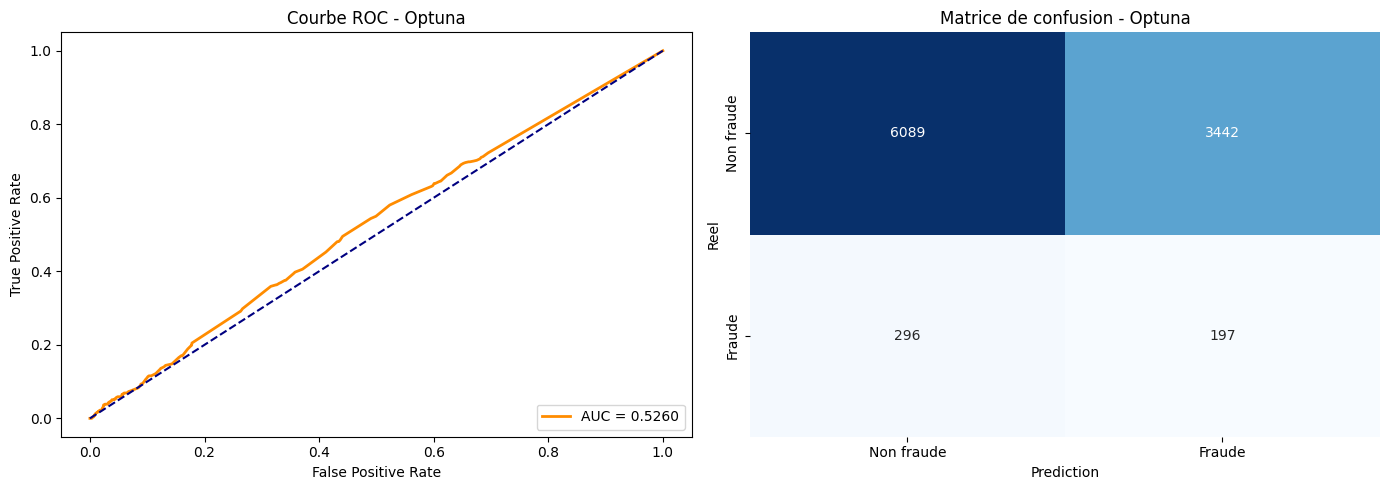

AUC score Optuna : 0.5260


0.5259639570501554

In [113]:
optuna_model = DecisionTreeClassifier(**optuna_best_params)    
optuna_model.fit(X_train, y_train)
val_pred_optuna = optuna_model.predict(X_test)
val_proba_optuna = optuna_model.predict_proba(X_test)[:, 1]
auc_optuna = roc_auc_score(y_test, val_proba_optuna)


print("Meilleurs parametres Optuna:")
print(optuna_best_params)
print(f"Meilleure AUC CV: {optuna_best_cv_auc:.4f}")
print(f"AUC sur le jeu de test : {auc_optuna:.4f}")
draw_tree_model(optuna_model, X_train.columns, "Optuna", max_depth=3)
plot_auc_and_confusion(optuna_model, X_test, y_test, "Optuna")


> Même avec Optuna, les performances restent tres proches d'un comportement aleatoire. Cela renforce l'idee que la limite principale vient surtout des donnees disponibles et du faible pouvoir discriminant des variables actuelles, plus que du choix du modele lui-meme.

### Comparaison des methodes

Le graphique suivant permet de comparer rapidement les AUC obtenues par la baseline, RandomizedSearchCV et Optuna.

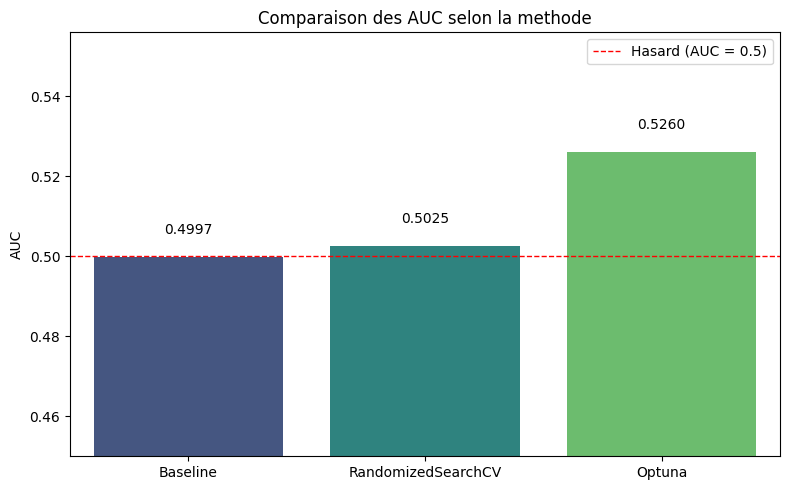

,Methode,AUC
0,Baseline,0.499737
1,RandomizedSearchCV,0.502550
2,Optuna,0.525964


In [114]:
comparison_df = pd.DataFrame({
    'Methode': ['Baseline', 'RandomizedSearchCV', 'Optuna'],
    'AUC': [auc_baseline, auc_randomized, auc_optuna]
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=comparison_df, x='Methode', y='AUC', hue='Methode', palette='viridis', legend=False)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Hasard (AUC = 0.5)')

for i, value in enumerate(comparison_df['AUC']):
    ax.text(i, value + 0.005, f'{value:.4f}', ha='center', va='bottom')

plt.ylim(0.45, max(0.55, comparison_df['AUC'].max() + 0.03))
plt.title('Comparaison des AUC selon la methode')
plt.ylabel('AUC')
plt.xlabel('')
plt.legend()
plt.tight_layout()
plt.show()

comparison_df

**Conclusion** : On remarque que notre arbre de decision n'arrive pas vraiment a distinguer les deux classes. Les scores restent tres proches d'un comportement aleatoire, ce qui va dans le meme sens que notre observation lors de l'analyse des boxplots : les distributions des deux classes se ressemblent beaucoup.

Cela suggere que la difficulte vient surtout des donnees disponibles. Avec les variables actuelles, le modele dispose de peu d'information pour separer clairement les transactions frauduleuses des transactions non frauduleuses.

Enfin, l'optimisation des hyperparametres avec RandomizedSearchCV et Optuna permet une legere amelioration, mais ce gain reste limite et ne change pas le constat principal.